# 雅可比矩阵与向量链式法则 - 可视化

本 Notebook 生成三张图：
1. 网格映射形变（直观感受雅可比）
2. 某点附近线性近似（Jacobian 作为局部线性变换）
3. 向量链式法则流程图

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/01_微积分/assets')

## 定义一个二维映射

In [2]:
def f(x, y):
    # 一个带非线性的二维映射
    u = x + 0.6*y
    v = 0.3*x + y + 0.2*x**2
    return u, v

def jacobian(x, y):
    # 对应映射的雅可比矩阵
    # u_x=1, u_y=0.6; v_x=0.3+0.4x, v_y=1
    return np.array([[1.0, 0.6], [0.3 + 0.4*x, 1.0]])

## 图1：网格映射形变

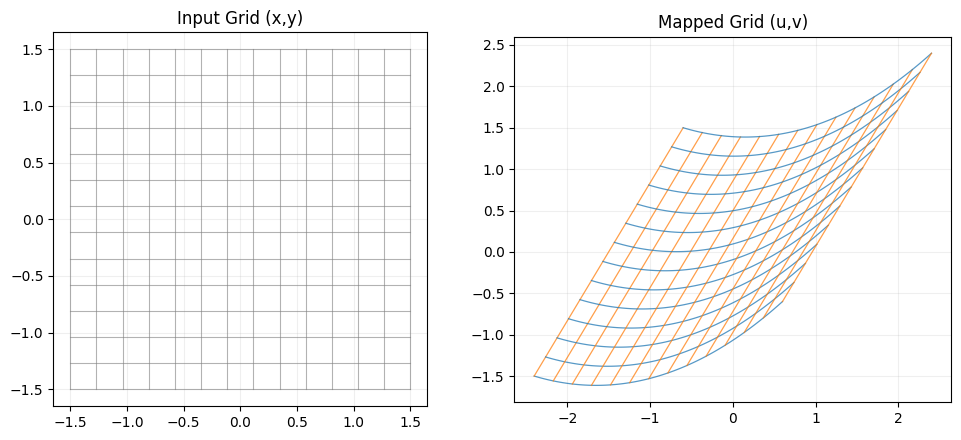

In [3]:
grid = np.linspace(-1.5, 1.5, 14)

plt.figure(figsize=(10,4.5))

# 原始网格
ax1 = plt.subplot(1,2,1)
for c in grid:
    xs = np.linspace(-1.5, 1.5, 120)
    ys = np.full_like(xs, c)
    ax1.plot(xs, ys, color='gray', alpha=0.6, linewidth=0.8)
    ys2 = np.linspace(-1.5, 1.5, 120)
    xs2 = np.full_like(ys2, c)
    ax1.plot(xs2, ys2, color='gray', alpha=0.6, linewidth=0.8)
ax1.set_title('Input Grid (x,y)')
ax1.set_aspect('equal', 'box')
ax1.grid(alpha=0.2)

# 映射后网格
ax2 = plt.subplot(1,2,2)
for c in grid:
    xs = np.linspace(-1.5, 1.5, 120)
    ys = np.full_like(xs, c)
    u, v = f(xs, ys)
    ax2.plot(u, v, color='tab:blue', alpha=0.75, linewidth=0.9)

    ys2 = np.linspace(-1.5, 1.5, 120)
    xs2 = np.full_like(ys2, c)
    u2, v2 = f(xs2, ys2)
    ax2.plot(u2, v2, color='tab:orange', alpha=0.75, linewidth=0.9)

ax2.set_title('Mapped Grid (u,v)')
ax2.set_aspect('equal', 'box')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(assets_dir / '13_mapping_deformation.png', dpi=160)
plt.show()

## 图2：某点附近线性近似（Jacobian）

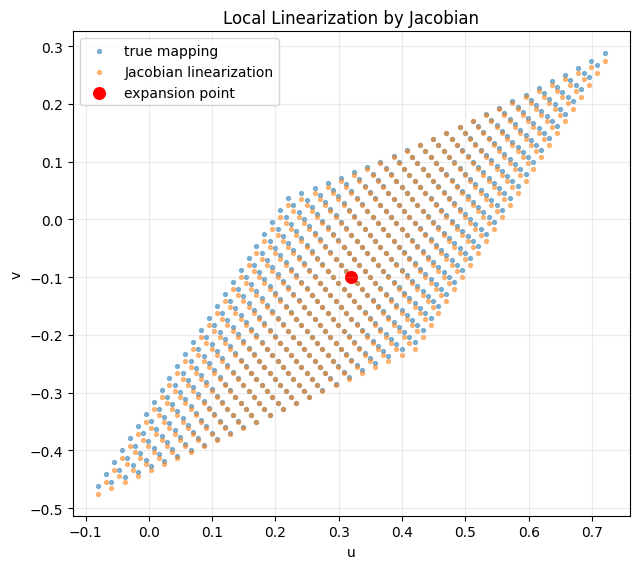

In [4]:
x0, y0 = 0.5, -0.3
u0, v0 = f(x0, y0)
J0 = jacobian(x0, y0)

# 小邻域点
delta = np.linspace(-0.25, 0.25, 25)
DX, DY = np.meshgrid(delta, delta)
Xn, Yn = x0 + DX, y0 + DY

# 真映射
U_true, V_true = f(Xn, Yn)

# 线性近似: f(x0+dx,y0+dy) ≈ f(x0,y0) + J0*[dx,dy]^T
DU = J0[0,0]*DX + J0[0,1]*DY
DV = J0[1,0]*DX + J0[1,1]*DY
U_lin = u0 + DU
V_lin = v0 + DV

plt.figure(figsize=(6.5,5.8))
plt.scatter(U_true, V_true, s=8, alpha=0.5, label='true mapping')
plt.scatter(U_lin, V_lin, s=8, alpha=0.5, label='Jacobian linearization')
plt.scatter([u0], [v0], c='red', s=70, label='expansion point')
plt.title('Local Linearization by Jacobian')
plt.xlabel('u')
plt.ylabel('v')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '14_local_linearization.png', dpi=160)
plt.show()

## 图3：向量链式法则流程图

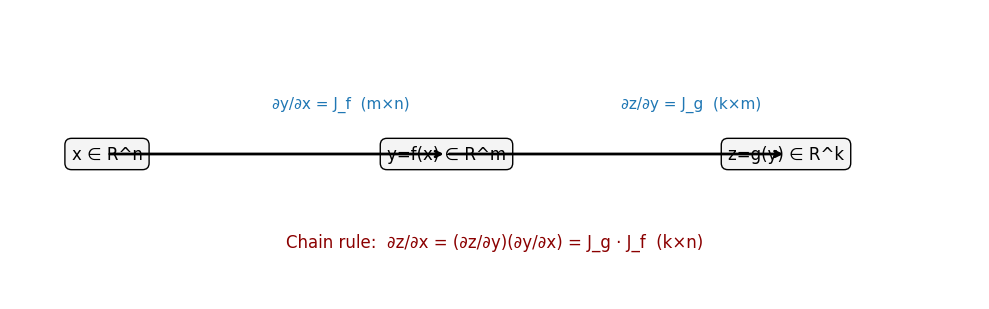

In [5]:
fig, ax = plt.subplots(figsize=(10,3.2))
ax.axis('off')

nodes = {
    'x ∈ R^n': (0.10, 0.5),
    'y=f(x) ∈ R^m': (0.45, 0.5),
    'z=g(y) ∈ R^k': (0.80, 0.5),
}
for label, (xx, yy) in nodes.items():
    ax.text(xx, yy, label, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.4', fc='#f4f4f4', ec='black'))

arrow = dict(arrowstyle='->', lw=2)
ax.annotate('', xy=nodes['y=f(x) ∈ R^m'], xytext=nodes['x ∈ R^n'], arrowprops=arrow)
ax.annotate('', xy=nodes['z=g(y) ∈ R^k'], xytext=nodes['y=f(x) ∈ R^m'], arrowprops=arrow)

ax.text(0.27, 0.66, '∂y/∂x = J_f  (m×n)', color='tab:blue', fontsize=11)
ax.text(0.63, 0.66, '∂z/∂y = J_g  (k×m)', color='tab:blue', fontsize=11)
ax.text(0.50, 0.18, 'Chain rule:  ∂z/∂x = (∂z/∂y)(∂y/∂x) = J_g · J_f  (k×n)',
        ha='center', color='darkred', fontsize=12)

plt.tight_layout()
plt.savefig(assets_dir / '15_vector_chain_rule.png', dpi=160)
plt.show()

### 输出文件
- `assets/13_mapping_deformation.png`
- `assets/14_local_linearization.png`
- `assets/15_vector_chain_rule.png`